<a href="https://colab.research.google.com/github/marcuscheung02/PY191_lab/blob/main/week_2_day1_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

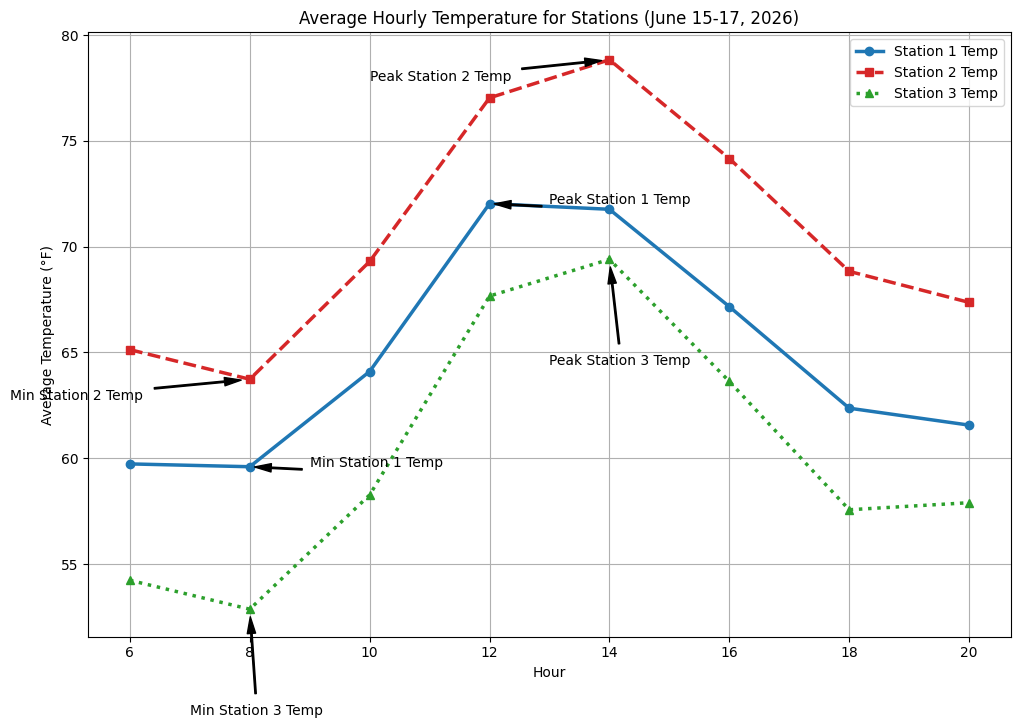

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

station_df = pd.read_csv("station_weather.csv")

station_df['date'] = pd.to_datetime(station_df['date'])

date_1 = pd.to_datetime("2026-06-15")
date_2 = pd.to_datetime("2026-06-16")
date_3 = pd.to_datetime("2026-06-17")

station1_data = station_df[station_df["station_id"] == "RISE-01"]
station2_data = station_df[station_df["station_id"] == "RISE-02"]
station3_data = station_df[station_df["station_id"] == "RISE-03"]

station1day1 = station1_data.loc[station1_data["date"] == date_1, "temperature_f"].values
station1day2 = station1_data.loc[station1_data["date"] == date_2, "temperature_f"].values
station1day3 = station1_data.loc[station1_data["date"] == date_3, "temperature_f"].values

station2day1 = station2_data.loc[station2_data["date"] == date_1, "temperature_f"].values
station2day2 = station2_data.loc[station2_data["date"] == date_2, "temperature_f"].values
station2day3 = station2_data.loc[station2_data["date"] == date_3, "temperature_f"].values

station3day1 = station3_data.loc[station3_data["date"] == date_1, "temperature_f"].values
station3day2 = station3_data.loc[station3_data["date"] == date_2, "temperature_f"].values
station3day3 = station3_data.loc[station3_data["date"] == date_3, "temperature_f"].values

station1avg = (station1day1 + station1day2 + station1day3) / 3
station2avg = (station2day1 + station2day2 + station2day3) / 3
station3avg = (station3day1 + station3day2 + station3day3) / 3

hour = station1_data.loc[station1_data["date"] == date_1, "hour"].values

fig, ax1 = plt.subplots(figsize=(10,7))

ax1.plot(hour, station1avg, color='#1f77b4', linestyle='-', marker='o', linewidth=2.5, label='Station 1 Temp')
ax1.plot(hour, station2avg, color='#d62728', linestyle='--', marker='s', linewidth=2.5, label='Station 2 Temp')
ax1.plot(hour, station3avg, color='#2ca02c', linestyle=':', marker='^', linewidth = 2.5, label='Station 3 Temp')

ax1.set_xlabel("Hour")
ax1.set_ylabel("Average Temperature (°F)")
ax1.set_title("Average Hourly Temperature for Stations (June 15-17, 2026)")
ax1.legend()
ax1.grid(True)
plt.xticks(hour)
plt.tight_layout()

# Annotate peaks (moved before plt.show() and adjusted coordinates/labels)
# Find approximate peak hour for each station from the 'hour' array (e.g., around hour 14)
# Note: The exact peak might vary, these are illustrative coordinates.
peak_hour_s1 = hour[np.argmax(station1avg)]
peak_temp_s1 = np.max(station1avg)
ax1.annotate('Peak Station 1 Temp',
             xy=(peak_hour_s1, peak_temp_s1),
             xytext=(peak_hour_s1 + 1, peak_temp_s1),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

peak_hour_s2 = hour[np.argmax(station2avg)]
peak_temp_s2 = np.max(station2avg)
ax1.annotate('Peak Station 2 Temp',
             xy=(peak_hour_s2, peak_temp_s2),
             xytext=(peak_hour_s2 - 4, peak_temp_s2 - 1),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

peak_hour_s3 = hour[np.argmax(station3avg)]
peak_temp_s3 = np.max(station3avg)
ax1.annotate('Peak Station 3 Temp',
             xy=(peak_hour_s3, peak_temp_s3),
             xytext=(peak_hour_s3 - 1, peak_temp_s3 - 5),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))


min_hour_s1 = hour[np.argmin(station1avg)]
min_temp_s1 = np.min(station1avg)
ax1.annotate('Min Station 1 Temp',
             xy=(min_hour_s1, min_temp_s1),
             xytext=(min_hour_s1 + 1, min_temp_s1),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

min_hour_s2 = hour[np.argmin(station2avg)]
min_temp_s2 = np.min(station2avg)
ax1.annotate('Min Station 2 Temp',
             xy=(min_hour_s2, min_temp_s2),
             xytext=(min_hour_s2 - 4, min_temp_s2 - 1),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

min_hour_s3 = hour[np.argmin(station3avg)]
min_temp_s3 = np.min(station3avg)
ax1.annotate('Min Station 3 Temp',
             xy=(min_hour_s3, min_temp_s3),
             xytext=(min_hour_s3 - 1, min_temp_s3 - 5),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

plt.show()

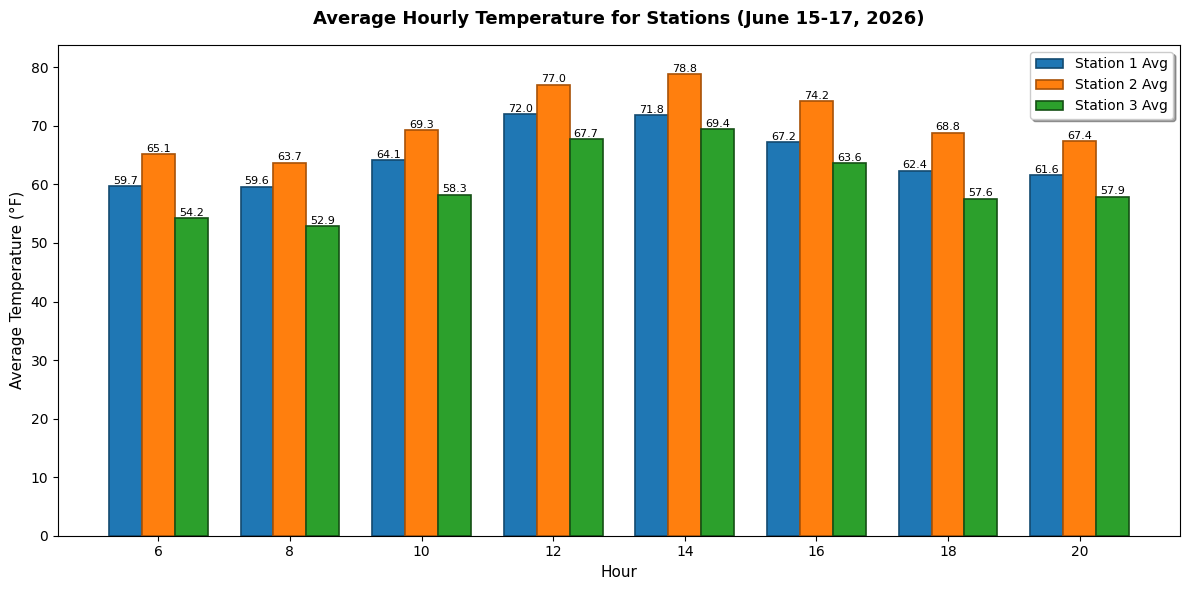

In [ ]:
categories = ['Station 1', 'Station 2', 'Station 3']

# x_indexes now represent the hours
x_indexes = np.arange(len(hour)) # hour has 8 elements

bar_width = 0.25 # width for each station's bar

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for each station at each hour
# For each hour x_index, we will have three bars:
# x_index - bar_width, x_index, x_index + bar_width

bars1 = ax.bar(x_indexes - bar_width, station1avg, width=bar_width,
               color='#1f77b4', edgecolor='#134a70', linewidth=1.2, label='Station 1 Avg')

bars2 = ax.bar(x_indexes, station2avg, width=bar_width,
               color='#ff7f0e', edgecolor='#a85207', linewidth=1.2, label='Station 2 Avg')

bars3 = ax.bar(x_indexes + bar_width, station3avg, width=bar_width,
               color='#2ca02c', edgecolor='#155015', linewidth=1.2, label='Station 3 Avg')

# Overwrite the raw numeric X-indexes back to readable text labels (hours)
ax.set_xticks(x_indexes)
ax.set_xticklabels(hour) # Use the 'hour' array for labels

# Add text labels to bars
for b1, b2, b3 in zip(bars1, bars2, bars3):
    ax.text(b1.get_x() + b1.get_width()/2, b1.get_height() + 0.4,
            f"{b1.get_height():.1f}", ha='center', fontsize=8)
    ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 0.4,
            f"{b2.get_height():.1f}", ha='center', fontsize=8)
    ax.text(b3.get_x() + b3.get_width()/2, b3.get_height() + 0.4,
            f"{b3.get_height():.1f}", ha='center', fontsize=8)

# Formatting polish
ax.set_title("Average Hourly Temperature for Stations (June 15-17, 2026)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Hour", fontsize=11)
ax.set_ylabel("Average Temperature (°F)", fontsize=11)

# Dynamically set y-limit based on the maximum temperature across all stations and hours
all_temps = np.concatenate((station1avg, station2avg, station3avg))
ax.set_ylim(0, np.max(all_temps) + 5)

ax.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()